In [1]:
!pip install -q transformers torch torchvision pillow matplotlib


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

In [4]:
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForSemanticSegmentation.from_pretrained(model_name)

print("Model loaded successfully!")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

C:\Users\srish\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\srish\.cache\huggingface\hub\models--nvidia--segformer-b0-finetuned-ade-512-512. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

C:\Users\srish\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\srish\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Model loaded successfully!


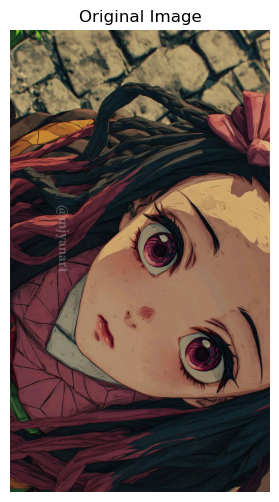

In [11]:
image = Image.open("task 8/image1.jpeg").convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [13]:
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

print("Segmentation completed!")

Segmentation completed!


In [15]:
logits = outputs.logits

# Resize prediction to original image size
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

predicted_mask = upsampled_logits.argmax(dim=1)[0]

mask = predicted_mask.cpu().numpy()

print("Mask shape:", mask.shape)

Mask shape: (1308, 736)


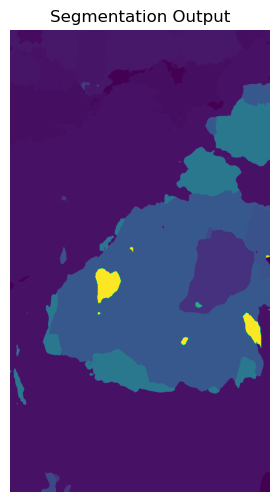

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(mask)
plt.axis("off")
plt.title("Segmentation Output")
plt.show()

In [19]:
id2label = model.config.id2label

unique_classes = np.unique(mask)

print("Detected classes:")

for class_id in unique_classes:
    print(class_id, "→", id2label[class_id])

Detected classes:
0 → wall
2 → sky
3 → floor
4 → tree
5 → ceiling
7 → bed 
8 → windowpane
9 → grass
20 → car
23 → sofa
24 → shelf
30 → armchair
31 → seat
36 → lamp
39 → cushion
57 → pillow
90 → airplane
142 → plate


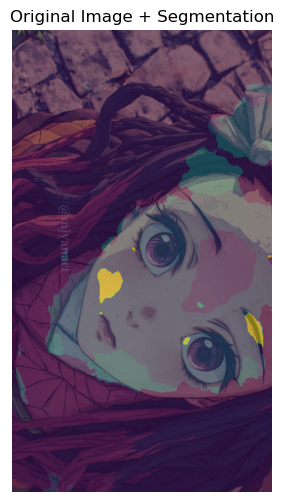

In [21]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.imshow(mask, alpha=0.5)

plt.axis("off")
plt.title("Original Image + Segmentation")
plt.show()